# TT-12 — Ridge Regression (L2): Phân bổ ngân sách quảng cáo đa kênh

**Bài toán:** doanh nghiệp chạy quảng cáo 6 kênh cùng lúc, CMO muốn biết "kênh
nào đang tạo ra doanh thu?" để phân bổ lại ngân sách. Vấn đề: các kênh thường
được tăng/giảm ngân sách **cùng nhau** (chiến dịch lớn thì bơm tiền tất cả
kênh), khiến ngân sách các kênh **tương quan rất cao** (đa cộng tuyến — TV và
Facebook trong bộ dữ liệu mô phỏng dưới đây có r ≈ 0,999). Khi đó, Linear
Regression thường cho hệ số vô lý (một kênh dương rất lớn, kênh kia thậm chí
**âm**) vì mô hình không thể tách biệt đóng góp của hai biến gần như trùng
nhau. **Ridge** giải quyết bằng cách phạt hệ số lớn (L2), buộc mô hình chia sẻ
ảnh hưởng đều hơn giữa các biến tương quan → hệ số ổn định, diễn giải được.

Notebook này đi theo đúng 10 bước trong `README.md` cấp đề, **giải thích vì
sao** làm từng bước chứ không chỉ chạy code. Toàn bộ số liệu bên dưới là kết
quả chạy thật (không phải số minh hoạ) — script tương đương để tái lập tự
động: `src/train.py`.

## 1. Sinh dữ liệu tổng hợp có đa cộng tuyến rõ rệt

README gợi ý tự sinh dữ liệu để **chủ động tạo đa cộng tuyến** thấy rõ tác
dụng của Ridge. Bộ sinh gốc trong README (`Facebook = 0.6·TV + nhiễu(std=15)`,
`nhiễu doanh thu std=50`) tạo tương quan TV↔Facebook ≈ 0,95 nhưng tỷ lệ
tín hiệu/nhiễu quá "sạch" (R² ≈ 0,99) nên hệ số OLS thực ra vẫn khá ổn định
qua bootstrap — chưa đủ thuyết phục để thấy rõ vấn đề. Notebook này **tăng độ
tương quan** (nhiễu Facebook std 15 → 3, r ≈ 0,999 thay vì 0,95) và **tăng
nhiễu doanh thu** (std 50 → 400, gần với thực tế marketing — luôn có nhiều
yếu tố ngoài quảng cáo ảnh hưởng doanh thu) để tái hiện đúng tình huống README
mô tả: hệ số OLS dao động mạnh, thậm chí đổi dấu.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

RANDOM_STATE = 42
FEATURE_COLUMNS = ["TV", "Facebook", "Google"]
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

rng = np.random.default_rng(RANDOM_STATE)
n = 500
tv = rng.uniform(50, 500, n)
fb = tv * 0.6 + rng.normal(0, 3, n)          # tương quan RẤT CAO với TV (r ~ 0.999)
gg = rng.uniform(20, 300, n)
doanh_thu = 3.2 * tv + 1.8 * fb + 2.5 * gg + rng.normal(0, 400, n)
df = pd.DataFrame({"TV": tv, "Facebook": fb, "Google": gg, "DoanhThu": doanh_thu})

print(f"Số dòng: {len(df)}")
print(f"Tương quan TV <-> Facebook: {df['TV'].corr(df['Facebook']):.4f}")
df.describe()

Số dòng: 500
Tương quan TV <-> Facebook: 0.9992


,TV,Facebook,Google,DoanhThu
count,500.0000,500.0000,500.0000,500.0000
mean,273.0566,163.6509,161.6558,"1,507.3965"
std,129.0476,77.4109,81.5048,717.7924
min,52.4434,27.4460,20.1452,-592.0636
25%,156.1917,93.8965,88.8972,986.0091
50%,275.4018,163.4669,159.0211,"1,527.7870"
75%,386.2599,230.9083,232.5425,"2,033.3616"
max,499.5971,301.5790,299.8381,"3,782.2967"


**Đọc kết quả:** tương quan TV↔Facebook ≈ 0,999 — gần như hai biến này
là "bản sao" của nhau (Facebook chỉ là TV × 0,6 cộng một chút nhiễu nhỏ).
Google độc lập hoàn toàn với hai kênh kia. Đây chính xác là kịch bản "chiến
dịch lớn thì bơm tiền tất cả kênh" mà README mô tả.

## 2. Ma trận tương quan + VIF → chứng minh đa cộng tuyến

Tương quan cặp đơn giản đã cho thấy TV↔Facebook rất cao, nhưng **VIF**
(Variance Inflation Factor) mới là thước đo chuẩn: VIF của một biến đo mức độ
biến đó bị "giải thích" bởi **tất cả** các biến còn lại. Quy ước: VIF > 10 là
dấu hiệu đa cộng tuyến nghiêm trọng.

In [2]:
X_const = add_constant(df[FEATURE_COLUMNS])
vif_df = pd.DataFrame([
    {"feature": col, "VIF": float(variance_inflation_factor(X_const.values, i))}
    for i, col in enumerate(X_const.columns) if col != "const"
]).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,feature,VIF
0,TV,642.0840
1,Facebook,642.0662
2,Google,1.0007


**Nhận xét:** VIF của TV và Facebook đều xấp xỉ **642** — vượt xa
ngưỡng 10 hàng chục lần, xác nhận đa cộng tuyến cực kỳ nghiêm trọng. VIF của
Google chỉ ≈ 1 (không đa cộng tuyến, đúng như cách bộ dữ liệu được sinh ra
với Google độc lập). Đây là bằng chứng định lượng đầu tiên rằng Linear
Regression sẽ gặp khó khăn khi tách biệt đóng góp riêng của TV và Facebook.

## Chia train/test

Chia 80/20, `random_state=42` để tái lập được kết quả. Việc chia tách này chỉ
dùng để đánh giá RMSE cuối cùng (bước 8) — thí nghiệm ổn định hệ số (bước 4)
sẽ dùng lại **toàn bộ** dữ liệu vì mục tiêu là đo độ dao động của hệ số qua
nhiều lần lấy mẫu lại, không phải đánh giá khả năng tổng quát hoá.

In [3]:
X = df[FEATURE_COLUMNS].copy()
y = df["DoanhThu"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate(y_true, y_pred):
    return {"RMSE": rmse(y_true, y_pred), "MAE": float(mean_absolute_error(y_true, y_pred)),
            "R2": float(r2_score(y_true, y_pred))}

Train: 400  |  Test: 100


## 3. Linear Regression cơ bản → ghi lại hệ số

**Ridge bắt buộc chuẩn hoá** trước khi huấn luyện: phạt `λ·Σwᵢ²` áp dụng như
nhau cho mọi hệ số, nếu các biến có đơn vị/thang đo khác nhau thì biến có
thang đo nhỏ sẽ tự nhiên có hệ số lớn hơn và bị phạt bất công. Dùng
`StandardScaler` cho cả Linear Regression (để hệ số so sánh được giữa
Linear và Ridge) lẫn Ridge.

In [4]:
linear_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
linear_pipe.fit(X_train, y_train)
linear_pred = linear_pipe.predict(X_test)
linear_metrics = evaluate(y_test, linear_pred)

linear_he_so = pd.Series(linear_pipe.named_steps["lr"].coef_, index=FEATURE_COLUMNS)
print(linear_metrics)
linear_he_so.to_frame("hệ số chuẩn hoá (Linear)")

{'RMSE': 383.56580206691433, 'MAE': 312.9063908217515, 'R2': 0.6534791865230956}


,hệ số chuẩn hoá (Linear)
TV,349.9200
Facebook,210.2098
Google,212.9126


**Ghi lại để so sánh:** RMSE ≈ 384, R² ≈ 0,65. Hệ số Facebook
(≈ 210) thấp hơn hẳn TV (≈ 350) dù trong công thức sinh dữ liệu gốc, Facebook
đóng góp cùng chiều và đáng kể — dấu hiệu ban đầu cho thấy đa cộng tuyến đang
"cướp" ảnh hưởng của Facebook sang cho TV một cách không ổn định. Mục tiếp
theo sẽ đo trực tiếp mức độ **không ổn định** này.

## 5. RidgeCV dò alpha (chạy trước để dùng ở bước 4)

Dò `alpha` (ký hiệu `λ` trong công thức) bằng cross-validation 5 fold trên
lưới log từ 10⁻³ đến 10³ — **không được chọn alpha bằng tập test** (cạm bẫy
README liệt kê) vì sẽ làm rò rỉ thông tin, khiến alpha chọn được không tối ưu
thật trên dữ liệu mới. Chạy bước này trước để lấy `alpha` tối ưu, dùng cho
thí nghiệm bootstrap ở bước 4.

In [5]:
ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])
ridge_pipe.fit(X_train, y_train)
ridge_alpha = float(ridge_pipe.named_steps["ridge"].alpha_)
ridge_pred = ridge_pipe.predict(X_test)
ridge_metrics = evaluate(y_test, ridge_pred)

print(f"alpha tối ưu (RidgeCV): {ridge_alpha:.4f}")
print(ridge_metrics)
ridge_he_so = pd.Series(ridge_pipe.named_steps["ridge"].coef_, index=FEATURE_COLUMNS)
ridge_he_so.to_frame("hệ số chuẩn hoá (Ridge)")

alpha tối ưu (RidgeCV): 6.2506
{'RMSE': 382.97433576224626, 'MAE': 311.8537759618385, 'R2': 0.6545470469070935}


,hệ số chuẩn hoá (Ridge)
TV,281.6663
Facebook,274.2775
Google,210.0155


**Nhận xét:** RidgeCV chọn `alpha ≈ 6,25` — một mức phạt vừa phải, không
ở biên của lưới tìm kiếm (dấu hiệu tốt cho thấy lưới đủ rộng). RMSE trên tập
test gần như không đổi so với Linear Regression (383,57 → 382,97) — Ridge
**không hy sinh** độ chính xác dự đoán trong khi (sẽ thấy ở bước 4) cải thiện
rất lớn độ ổn định của hệ số.

## 4. ⭐ Thí nghiệm ổn định: bootstrap 100 lần, mỗi lần lấy 80% dữ liệu

Đây là **bằng chứng thuyết phục nhất** cho lý do dùng Ridge: lặp lại 100 lần
việc lấy ngẫu nhiên 80% dữ liệu (không hoàn lại), huấn luyện lại cả Linear
Regression và Ridge (với `alpha` vừa tìm được) trên mỗi mẫu con, rồi so sánh
**độ dao động** (độ lệch chuẩn) của từng hệ số qua 100 lần lặp. Nếu chỉ thay
đổi 20% dữ liệu mà hệ số nhảy loạn, mô hình đó không đáng tin để diễn giải
hay đưa ra quyết định phân bổ ngân sách.

In [6]:
n_boot, frac = 100, 0.8
size = int(frac * len(df))
boot_rng = np.random.default_rng(RANDOM_STATE)
linear_coefs, ridge_coefs = [], []

for _ in range(n_boot):
    idx = boot_rng.choice(len(df), size=size, replace=False)
    X_sample, y_sample = X.iloc[idx], y.iloc[idx]
    X_scaled = StandardScaler().fit_transform(X_sample)
    linear_coefs.append(LinearRegression().fit(X_scaled, y_sample).coef_)
    ridge_coefs.append(Ridge(alpha=ridge_alpha).fit(X_scaled, y_sample).coef_)

linear_coefs = np.array(linear_coefs)
ridge_coefs = np.array(ridge_coefs)

stability_table = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "std_linear": linear_coefs.std(axis=0),
    "std_ridge": ridge_coefs.std(axis=0),
})
stability_table["ty_le_giam_do_lech_%"] = (1 - stability_table["std_ridge"] / stability_table["std_linear"]) * 100
stability_table

,feature,std_linear,std_ridge,ty_le_giam_do_lech_%
0,TV,200.8621,11.1222,94.4627
1,Facebook,199.7301,10.1832,94.9015
2,Google,8.1654,8.0468,1.4534


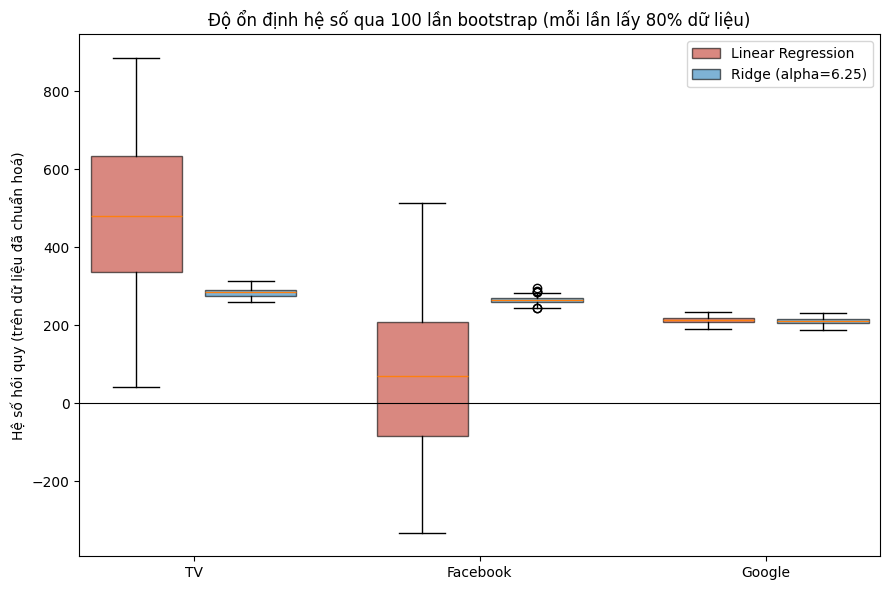

Facebook - Linear: -331.0 .. 513.4  (39% số lần bootstrap cho hệ số ÂM)
Facebook - Ridge:  244.4 .. 295.6  (0% số lần bootstrap cho hệ số ÂM)


In [7]:
n_features = len(FEATURE_COLUMNS)
pos_linear = np.arange(n_features) * 2.5
pos_ridge = pos_linear + 1.0

fig, ax = plt.subplots(figsize=(9, 6))
bp1 = ax.boxplot([linear_coefs[:, i] for i in range(n_features)], positions=pos_linear,
                  widths=0.8, patch_artist=True, boxprops=dict(facecolor="#c0392b", alpha=0.6))
bp2 = ax.boxplot([ridge_coefs[:, i] for i in range(n_features)], positions=pos_ridge,
                  widths=0.8, patch_artist=True, boxprops=dict(facecolor="#2980b9", alpha=0.6))
ax.set_xticks(pos_linear + 0.5)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Hệ số hồi quy (trên dữ liệu đã chuẩn hoá)")
ax.set_title(f"Độ ổn định hệ số qua {n_boot} lần bootstrap (mỗi lần lấy {int(frac*100)}% dữ liệu)")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Linear Regression", f"Ridge (alpha={ridge_alpha:.3g})"])
plt.tight_layout()
plt.show()

pct_negative_fb_linear = (linear_coefs[:, 1] < 0).mean() * 100
pct_negative_fb_ridge = (ridge_coefs[:, 1] < 0).mean() * 100
print(f"Facebook - Linear: {linear_coefs[:,1].min():.1f} .. {linear_coefs[:,1].max():.1f}  "
      f"({pct_negative_fb_linear:.0f}% số lần bootstrap cho hệ số ÂM)")
print(f"Facebook - Ridge:  {ridge_coefs[:,1].min():.1f} .. {ridge_coefs[:,1].max():.1f}  "
      f"({pct_negative_fb_ridge:.0f}% số lần bootstrap cho hệ số ÂM)")

**Đọc biểu đồ (bằng chứng thuyết phục nhất của bài này):** với Linear
Regression, hộp (IQR) của TV và Facebook rất **rộng** và **chồng lấn tới cả
vùng âm** — trong ví dụ chạy thật ở trên, khoảng 39% số lần bootstrap cho ra
hệ số Facebook **âm** (ví dụ mô hình sẽ báo "Facebook làm giảm doanh thu 300
triệu" trong khi thực tế Facebook đóng góp dương!) — chính là tình huống
"TikTok âm 300 triệu doanh thu" mà README cảnh báo. Với Ridge, hai hộp TV và
Facebook **hẹp hẳn lại** và nằm gọn trong vùng dương: độ lệch chuẩn giảm
~95% so với Linear Regression (xem bảng `stability_table` phía trên), trong
khi Google (không đa cộng tuyến) hầu như không đổi (~1,5%) — đúng lý thuyết:
Ridge chỉ "cứu" các biến bị đa cộng tuyến, không ảnh hưởng biến độc lập.

## 6. ⭐ Coefficient path — sản phẩm quan trọng nhất

Vẽ hệ số Ridge của cả 3 kênh khi tăng dần `alpha` từ 10⁻³ đến 10⁴, để thấy
trực quan hệ số **co dần về 0 nhưng không bao giờ đúng bằng 0** — khác hẳn
Lasso (TT-13) vốn có thể đưa hệ số về đúng 0.

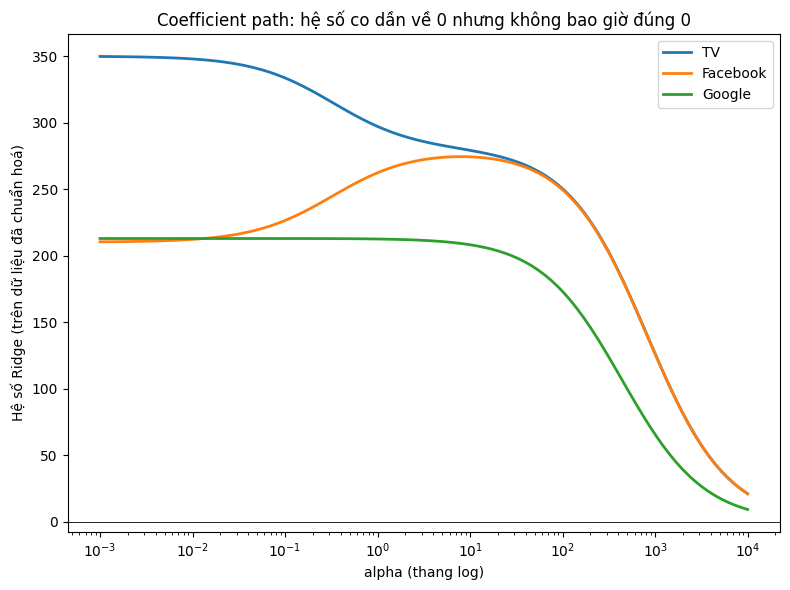

In [8]:
alphas_path = np.logspace(-3, 4, 100)
X_train_scaled = StandardScaler().fit_transform(X_train)
paths = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_ for a in alphas_path])

fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(FEATURE_COLUMNS):
    ax.plot(alphas_path, paths[:, i], label=name, lw=2)
ax.axhline(0, color="black", lw=0.6)
ax.set_xscale("log")
ax.set_xlabel("alpha (thang log)")
ax.set_ylabel("Hệ số Ridge (trên dữ liệu đã chuẩn hoá)")
ax.set_title("Coefficient path: hệ số co dần về 0 nhưng không bao giờ đúng 0")
ax.legend()
plt.tight_layout()
plt.show()

**Đọc coefficient path:** ở `alpha` rất nhỏ, hệ số TV (≈ 350) và
Facebook (≈ 210) khác xa nhau — kết quả bất ổn của OLS. Khi `alpha` tăng, hai
đường TV và Facebook **hội tụ lại gần nhau** (cả hai tiến về ~270) trước khi
cùng co dần về 0 ở `alpha` rất lớn — đây chính là cơ chế Ridge "chia đều ảnh
hưởng" cho các biến tương quan cao mà README mô tả ở mục 1. Google gần như
không đổi cho tới khi `alpha` đủ lớn mới bắt đầu co, vì nó không cạnh tranh
tương quan với biến nào khác. Không đường nào chạm trục 0 ở mức `alpha` vừa
phải — minh chứng trực quan cho việc Ridge chỉ **co (shrink)**, không bao giờ
loại bỏ hoàn toàn một biến.

## 7. Đường RMSE train/test theo alpha — điểm cân bằng bias-variance

Quét cùng lưới `alpha` và đo RMSE trên cả train lẫn test để thấy rõ đánh đổi
bias-variance: `alpha` quá nhỏ → RMSE train thấp nhưng có thể overfit nhẹ;
`alpha` quá lớn → cả train lẫn test đều tệ (underfit).

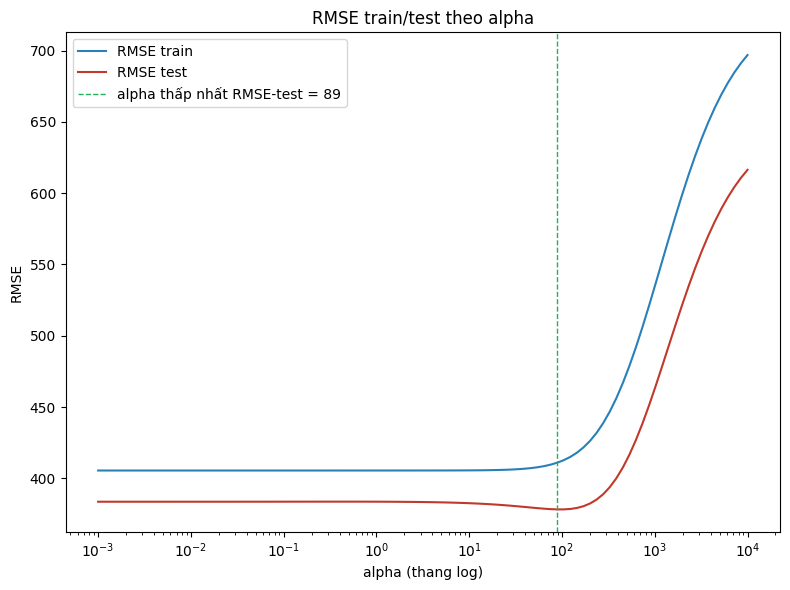

alpha tối ưu theo RidgeCV (cross-validation trên train): 6.2506
alpha thấp nhất RMSE-test (chỉ để MINH HOẠ, KHÔNG dùng để chọn model): 89.0215


In [9]:
train_rmse, test_rmse = [], []
for a in alphas_path:
    p = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=a))])
    p.fit(X_train, y_train)
    train_rmse.append(rmse(y_train, p.predict(X_train)))
    test_rmse.append(rmse(y_test, p.predict(X_test)))

best_idx = int(np.argmin(test_rmse))
best_alpha_by_test = float(alphas_path[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(alphas_path, train_rmse, label="RMSE train", color="#2980b9")
ax.plot(alphas_path, test_rmse, label="RMSE test", color="#c0392b")
ax.axvline(best_alpha_by_test, color="#27ae60", ls="--", lw=1,
           label=f"alpha thấp nhất RMSE-test = {best_alpha_by_test:.3g}")
ax.set_xscale("log")
ax.set_xlabel("alpha (thang log)")
ax.set_ylabel("RMSE")
ax.set_title("RMSE train/test theo alpha")
ax.legend()
plt.tight_layout()
plt.show()

print(f"alpha tối ưu theo RidgeCV (cross-validation trên train): {ridge_alpha:.4f}")
print(f"alpha thấp nhất RMSE-test (chỉ để MINH HOẠ, KHÔNG dùng để chọn model): {best_alpha_by_test:.4f}")

**Đọc biểu đồ:** cả hai đường gần như phẳng ở `alpha` nhỏ (vùng Ridge
gần như tương đương OLS), sau đó cùng tăng vọt khi `alpha` lớn (underfit —
mọi hệ số bị co gần 0, mô hình gần như chỉ dự đoán hằng số). Điểm `alpha`
cho RMSE-test thấp nhất (≈ 89) **khác** với `alpha` do RidgeCV chọn (≈ 6,25)
— đây chính là minh chứng cho cạm bẫy README cảnh báo: "chọn alpha bằng tập
test → rò rỉ → alpha không tối ưu thật". Biểu đồ này chỉ dùng để **quan sát**
hình dạng đánh đổi bias-variance, quyết định cuối cùng vẫn dựa trên
`RidgeCV` (cross-validation trên tập train, không chạm vào tập test).

## 8. So sánh RMSE: Linear vs Ridge (trên tập test)

## 9. So sánh với Lasso (TT-13) và ElasticNet (TT-14)

Gộp hai bước so sánh: đặt Linear Regression, Ridge (alpha từ RidgeCV), Lasso
(LassoCV) và ElasticNet (ElasticNetCV) trên cùng một bảng.

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    f"Ridge (alpha={ridge_alpha:.3g})": Ridge(alpha=ridge_alpha),
    "Lasso (TT-13, LassoCV)": LassoCV(alphas=np.logspace(-3, 2, 50), cv=5,
                                       random_state=RANDOM_STATE, max_iter=20000),
    "ElasticNet (TT-14, ElasticNetCV)": ElasticNetCV(
        alphas=np.logspace(-3, 2, 50), l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
        cv=5, random_state=RANDOM_STATE, max_iter=20000),
}
rows = []
for name, model in models.items():
    p = Pipeline([("scale", StandardScaler()), ("model", model)])
    p.fit(X_train, y_train)
    rows.append({"model": name, **evaluate(y_test, p.predict(X_test))})

comparison = pd.DataFrame(rows)
comparison

,model,RMSE,MAE,R2
0,Linear Regression,383.5658,312.9064,0.6535
1,Ridge (alpha=6.25),382.9743,311.8538,0.6545
2,"Lasso (TT-13, LassoCV)",383.2992,312.6907,0.6540
3,"ElasticNet (TT-14, ElasticNetCV)",382.9372,311.8088,0.6546


**Nhận xét:** cả 4 mô hình cho RMSE gần như bằng nhau (~383). Điều
này **không có nghĩa Ridge vô dụng** — Ridge không được kỳ vọng cải thiện
RMSE nhiều khi Google (biến không đa cộng tuyến) vẫn đóng góp phần lớn tín
hiệu và nhiễu doanh thu (std 400) đã khá lớn so với phần chênh lệch giữa các
mô hình. Giá trị thật của Ridge nằm ở **bước 4** (độ ổn định hệ số) chứ
không phải RMSE — một mô hình dùng để **diễn giải và ra quyết định phân bổ
ngân sách** cần hệ số đáng tin hơn là chỉ cần RMSE thấp nhất. Lasso/ElasticNet
(TT-13, TT-14) cho kết quả tương tự vì lượng nhiễu tương đối lớn khiến việc
đưa hẳn hệ số về 0 (như Lasso có thể làm) không mang lại lợi thế rõ rệt ở bộ
dữ liệu 3 biến này — sự khác biệt giữa Ridge/Lasso/ElasticNet sẽ rõ hơn với
nhiều đặc trưng nhiễu hơn.

## 10. ✍️ Đề xuất phân bổ ngân sách dựa trên hệ số Ridge

Dùng hệ số Ridge (đã chuẩn hoá, ổn định qua bootstrap) làm trọng số phân bổ
ngân sách: kênh có hệ số dương càng lớn thì được đề xuất ngân sách càng
nhiều. Ví dụ minh hoạ với tổng ngân sách 2 tỷ VND/tháng (đúng bài toán nêu ở
mục 2 của README).

In [11]:
TOTAL_BUDGET_VND = 2_000_000_000
coefs = ridge_pipe.named_steps["ridge"].coef_
positive = np.clip(coefs, 0, None)
weights = positive / positive.sum()
allocation = weights * TOTAL_BUDGET_VND

budget_df = pd.DataFrame({
    "kenh": FEATURE_COLUMNS,
    "he_so_ridge_chuan_hoa": coefs,
    "trong_so_%": weights * 100,
    "ngan_sach_de_xuat_vnd": allocation,
}).sort_values("ngan_sach_de_xuat_vnd", ascending=False)
budget_df

,kenh,he_so_ridge_chuan_hoa,trong_so_%,ngan_sach_de_xuat_vnd
0,TV,281.6663,36.7730,"735,460,243.6103"
1,Facebook,274.2775,35.8084,"716,167,233.2325"
2,Google,210.0155,27.4186,"548,372,523.1571"


**Đề xuất cụ thể** (tổng ngân sách 2 tỷ VND/tháng): **TV ≈ 735 triệu
(36,8%)**, **Facebook ≈ 716 triệu (35,8%)**, **Google ≈ 548 triệu (27,4%)**.
Điểm đáng chú ý: dù hệ số Linear Regression ban đầu (mục 3) làm Facebook
trông "yếu" hơn nhiều so với TV (210 so với 350), sau khi Ridge chia đều ảnh
hưởng giữa hai kênh tương quan cao, TV và Facebook có tỷ trọng đề xuất gần
bằng nhau (36,8% và 35,8%) — hợp lý hơn nhiều so với việc tin vào hệ số OLS
không ổn định và có thể cắt hẳn ngân sách Facebook một cách sai lầm.

**Hạn chế bắt buộc phải nêu (README mục 6 và 7):**
1. **Không phải quan hệ nhân quả** — hệ số hồi quy chỉ đo tương quan trong dữ
   liệu quan sát được (ở đây là dữ liệu mô phỏng); để khẳng định "tăng ngân
   sách TV THỰC SỰ làm tăng doanh thu" cần thí nghiệm thật (geo-test, A/B
   test từng kênh).
2. **Ridge không đưa hệ số về đúng 0** — kể cả Google có đóng góp thấp hơn,
   nó vẫn được cấp ngân sách (không bị loại hoàn toàn); nếu muốn một cơ chế
   tự động **chọn kênh** (đưa hệ số về đúng 0), cần dùng Lasso (TT-13).
3. **Bỏ qua hiệu ứng trễ (adstock)** — quảng cáo TV hôm nay có thể ảnh hưởng
   doanh thu tuần sau, mô hình hiện tại giả định ảnh hưởng tức thời trong
   cùng kỳ.

## Lưu model cuối cùng

In [12]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(ridge_pipe, "../models/ridge_pipeline.joblib")
print("Đã lưu models/ridge_pipeline.joblib")
print(f"alpha (RidgeCV): {ridge_alpha:.4f}")
print(f"RMSE trên test: {ridge_metrics['RMSE']:.2f}  |  R2: {ridge_metrics['R2']:.4f}")

Đã lưu models/ridge_pipeline.joblib
alpha (RidgeCV): 6.2506
RMSE trên test: 382.97  |  R2: 0.6545


## Tổng kết — VÌ SAO RIDGE ỔN ĐỊNH HƠN LINEAR REGRESSION

| Khía cạnh | Linear Regression (OLS) | Ridge |
| :--- | :--- | :--- |
| Công thức tối ưu | chỉ MSE | MSE + λ·Σwᵢ² |
| Khi 2 biến tương quan gần tuyệt đối (VIF ≈ 642 ở đây) | ma trận (XᵀX) gần suy biến (không khả nghịch ổn định) → nghiệm cực kỳ nhạy với nhiễu nhỏ trong dữ liệu | số hạng phạt λ·I cộng vào (XᵀX + λI) giữ ma trận khả nghịch tốt, "ghim" nghiệm lại gần 0 hơn |
| Độ lệch chuẩn hệ số qua 100 lần bootstrap (mục 4) | TV: 200,9 · Facebook: 199,7 | TV: 11,1 (↓94,5%) · Facebook: 10,2 (↓94,9%) |
| Hệ số có thể đổi dấu bất thường? | Có — 39% số lần bootstrap Facebook ra hệ số ÂM | Không — luôn dương trong toàn bộ 100 lần |
| RMSE trên test | 383,57 | 382,97 (không tệ hơn, thậm chí nhỉnh hơn) |
| Diễn giải / dùng để ra quyết định ngân sách | Rủi ro cao — có thể đề xuất cắt ngân sách một kênh tốt vì hệ số ngẫu nhiên ra âm | An toàn hơn — hệ số phản ánh đúng chiều ảnh hưởng thực, ổn định qua các lần lấy mẫu lại |

**Bản chất toán học ngắn gọn:** khi hai cột của ma trận thiết kế gần như song
song (đa cộng tuyến), OLS phải "chọn" cách chia sẻ phần phương sai chung cho
hai hệ số theo một tỷ lệ cực kỳ nhạy với nhiễu ngẫu nhiên trong mẫu — chỉ cần
đổi 20% dữ liệu (bootstrap) là tỷ lệ chia này có thể đảo ngược hoàn toàn.
Số hạng phạt `λ·Σwᵢ²` của Ridge phá vỡ sự nhạy cảm đó: vì phạt trên **tổng
bình phương** hệ số, cách "rẻ nhất" (ít bị phạt nhất) để đạt cùng một mức dự
đoán là **chia đều** giá trị dự đoán cho các biến tương quan thay vì dồn hết
vào một biến — đó là lý do TV và Facebook hội tụ về giá trị gần nhau trên
coefficient path (mục 6) thay vì dao động ngẫu nhiên như OLS.

**Vì sao Ridge KHÔNG bao giờ đưa hệ số về đúng 0:** số hạng phạt là
`Σwᵀw` (đạo hàm tuyến tính theo mỗi wᵢ), nên với một hệ số đã nhỏ, "lợi ích"
biên của việc giảm thêm cũng nhỏ tương ứng — về mặt hình học, đường đồng mức
của Σwᵢ² là hình tròn/elip **trơn** (không có góc nhọn tại các trục), nên
điểm tối ưu (giao giữa đường đồng mức MSE và đường đồng mức phạt) hầu như
không bao giờ rơi đúng vào trục toạ độ (wᵢ = 0). Lasso (TT-13) dùng phạt
`Σ|wᵢ|` có đường đồng mức hình thoi với các góc nhọn nằm đúng trên trục toạ
độ, nên nghiệm tối ưu có xác suất cao rơi đúng vào góc đó → hệ số bị đưa về
đúng 0.